In [6]:
import pandas as pd
import numpy as np

# Load data
df_train = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_train.csv')
df_val   = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_val.csv')
df_test  = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_test.csv')

datasets = {
    "Train": df_train,
    "Validation": df_val,
    "Test": df_test
}

def dataset_stats(df):
    total = len(df)
    pos = (df['label'] == 1).sum()
    neg = (df['label'] == 0).sum()
    return total, pos, neg, pos / total, neg / total

stats = []

for name, d in datasets.items():
    total, pos, neg, pos_ratio, neg_ratio = dataset_stats(d)
    stats.append([name, total, pos, neg, pos_ratio, neg_ratio])

stats_df = pd.DataFrame(
    stats,
    columns=["Split", "Total", "Blockers", "Non-blockers", "Blocker ratio", "Non-blocker ratio"]
)

print(stats_df)

# Overall statistics
df_all = pd.concat([df_train, df_val, df_test])
overall = dataset_stats(df_all)

print("\nOverall dataset:")
print(f"Total molecules: {overall[0]}")
print(f"Blockers: {overall[1]} ({overall[3]*100:.2f}%)")
print(f"Non-blockers: {overall[2]} ({overall[4]*100:.2f}%)")


        Split  Total  Blockers  Non-blockers  Blocker ratio  Non-blocker ratio
0       Train  16582     10343          6239       0.623749           0.376251
1  Validation   2073      1297           776       0.625663           0.374337
2        Test   2073      1263           810       0.609262           0.390738

Overall dataset:
Total molecules: 20728
Blockers: 12903 (62.25%)
Non-blockers: 7825 (37.75%)


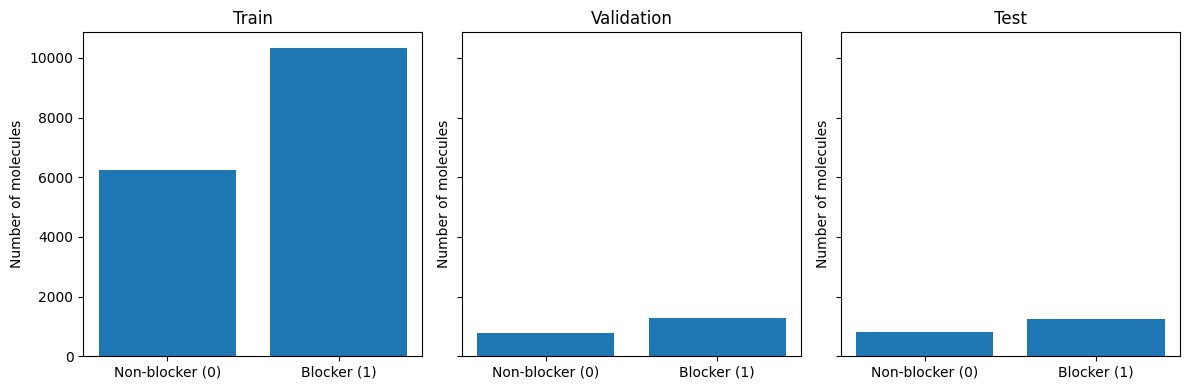

In [7]:
import matplotlib.pyplot as plt

labels = ['Non-blocker (0)', 'Blocker (1)']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, (name, d) in zip(axes, datasets.items()):
    counts = d['label'].value_counts().sort_index()
    ax.bar(labels, counts.values)
    ax.set_title(name)
    ax.set_ylabel("Number of molecules")

plt.tight_layout()
plt.savefig("fig_S1_class_distribution.png", dpi=300)
plt.show()


In [8]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def compute_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol)
    ]

props = df_all['smiles_standarized'].apply(compute_props)
props = props.dropna()

props_df = pd.DataFrame(props.tolist(), columns=["MolWt", "LogP", "TPSA"])


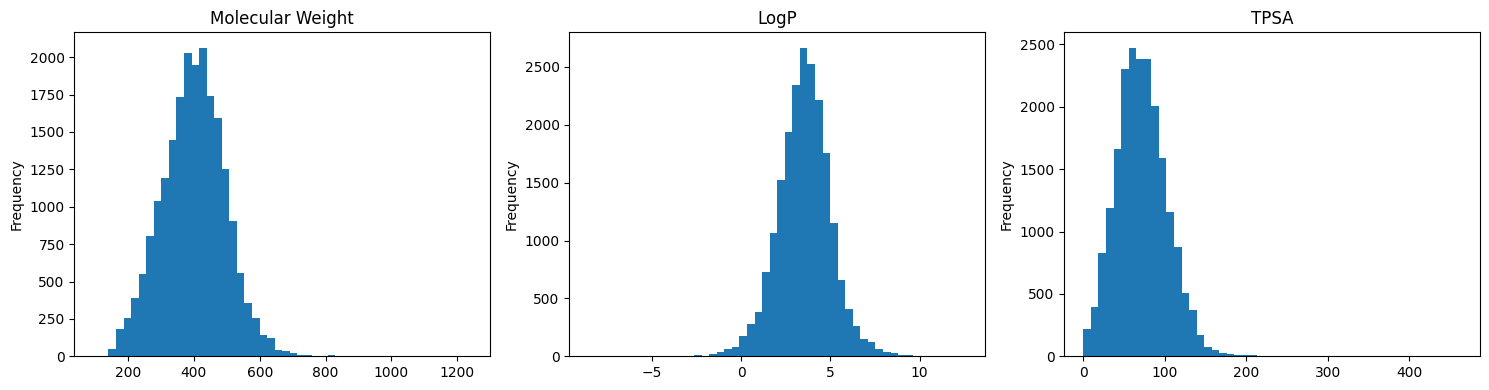

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(props_df["MolWt"], bins=50)
axes[0].set_title("Molecular Weight")

axes[1].hist(props_df["LogP"], bins=50)
axes[1].set_title("LogP")

axes[2].hist(props_df["TPSA"], bins=50)
axes[2].set_title("TPSA")

for ax in axes:
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig_S2_physchem_distributions.png", dpi=300)
plt.show()


In [10]:
herg_data = pd.read_csv("/home/f087s426/Research/Masters_Thesis/herg/hERG_IC50.csv")
herg_data=herg_data[['Smiles','pChEMBL Value']] 
herg_data=herg_data.dropna()
herg_data['SMILES']=herg_data['Smiles']
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# Load your data
#herg_data = pd.read_csv("toxic.csv")  # Replace with your actual filename

# Step 1: Remove rows with NaN SMILES
herg_data = herg_data[herg_data['SMILES'].notnull()]

# Step 2: Keep only the largest fragment of each molecule
def keep_largest_fragment(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            return None
        frags = Chem.GetMolFrags(mol, asMols=True)
        largest = max(frags, key=lambda m: rdMolDescriptors.CalcExactMolWt(m))
        return Chem.MolToSmiles(largest, canonical=True)
    except:
        return None

herg_data['SMILES'] = herg_data['SMILES'].apply(keep_largest_fragment)
herg_data = herg_data[herg_data['SMILES'].notnull()]

# Step 3: Export as .smi file (headerless if Deep-PK requires it)
herg_data[['SMILES']].head(50).to_csv("cleaned_input.smi", index=False, header=True)
from rdkit import Chem
from rdkit.Chem import Descriptors

def compute_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol)
    ]

props = herg_data['SMILES'].head(50).reset_index(drop=True).apply(compute_props)
props = props.dropna()

testprops_df = pd.DataFrame(props.tolist(), columns=["MolWt", "LogP", "TPSA"])

In [11]:
summary = pd.DataFrame({
    "Train Mean": props_df.mean(),
    "Test Mean": testprops_df.mean(),
    "Train Std": props_df.std(),
    "Test Std": testprops_df.std(),
})

print(summary)


       Train Mean   Test Mean  Train Std   Test Std
MolWt  399.621260  419.449140  95.644601  81.386479
LogP     3.535729    4.048457   1.475680   1.212035
TPSA    71.570369   58.842800  30.932712  22.603885


In [12]:
from scipy.stats import ks_2samp

print("KS Test p-values")
for col in ["MolWt", "LogP", "TPSA"]:
    stat, p = ks_2samp(props_df[col], testprops_df[col])
    print(f"{col}: p = {p:.6f}")


KS Test p-values
MolWt: p = 0.247209
LogP: p = 0.020963
TPSA: p = 0.000256


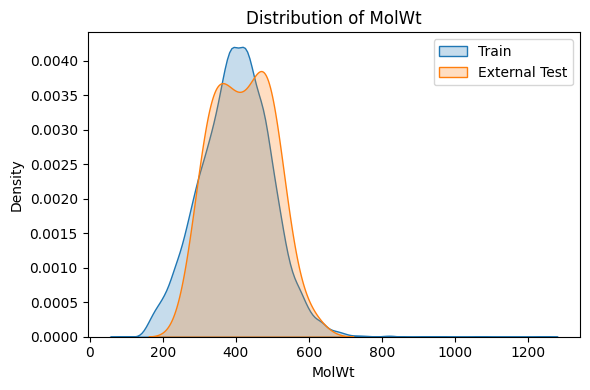

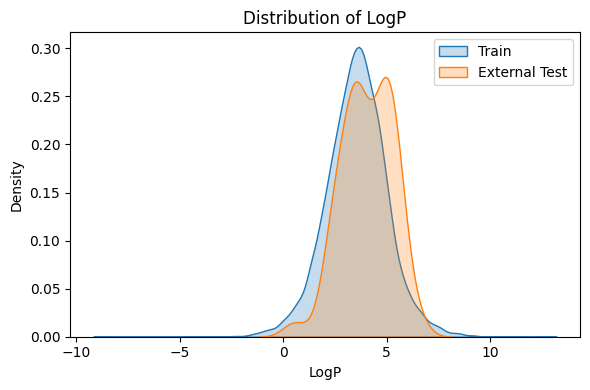

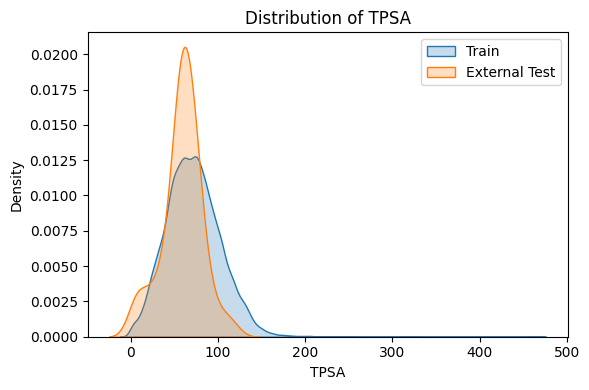

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ["MolWt", "LogP", "TPSA"]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(props_df[col], label="Train", fill=True)
    sns.kdeplot(testprops_df[col], label="External Test", fill=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


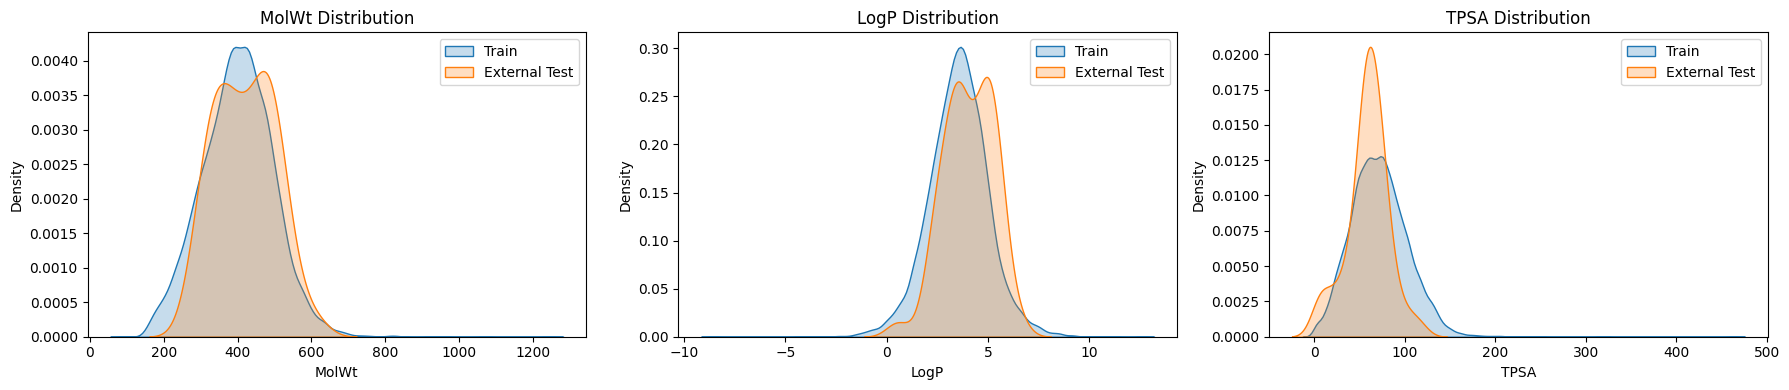

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(["MolWt", "LogP", "TPSA"]):
    sns.kdeplot(props_df[col], label="Train", fill=True, ax=axes[i])
    sns.kdeplot(testprops_df[col], label="External Test", fill=True, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.savefig("all_properties_distribution.png", dpi=300)
plt.show()


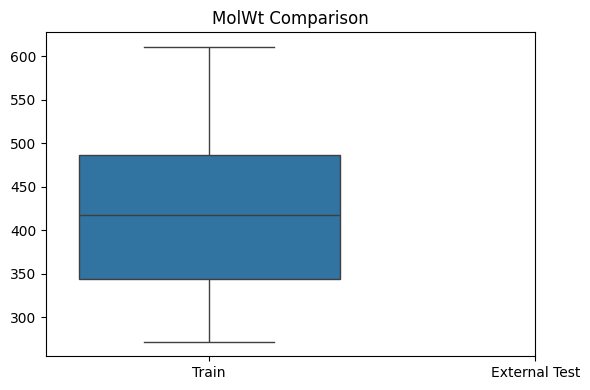

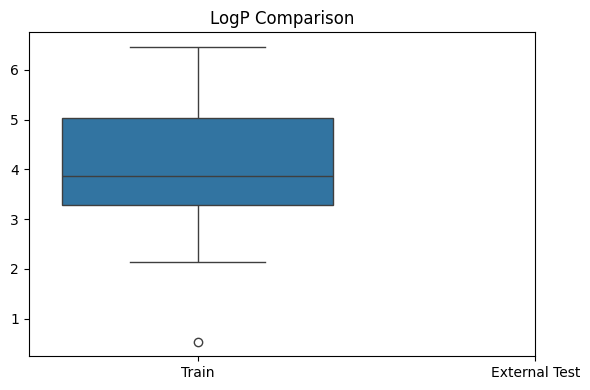

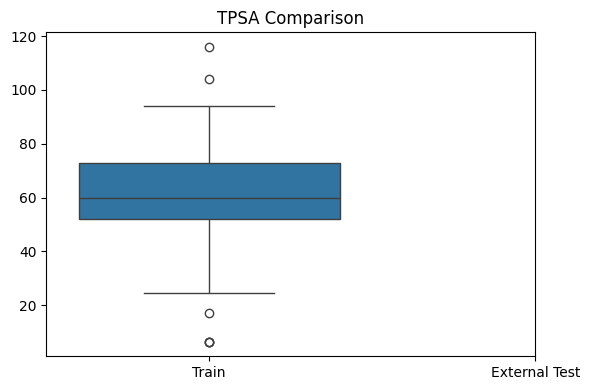

In [14]:
for col in ["MolWt", "LogP", "TPSA"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=[props_df[col], testprops_df[col]])
    plt.xticks([0,1], ["Train", "External Test"])
    plt.title(f"{col} Comparison")
    plt.tight_layout()
    plt.show()


In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, roc_auc_score, classification_report, accuracy_score
from rdkit import Chem
from rdkit.Chem import AllChem
import torch.nn as nn

# Load data
df_train = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_train.csv')
df_val = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_val.csv')
df_test = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_test.csv')
df = pd.concat([df_train, df_val, df_test])
df['smiles'] = df['smiles_standarized'].apply(lambda s: s.replace('\n', ''))
print(f"Total dataset size: {len(df)}")

# Load external test data
test_df = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/paper_valid_data.csv')
test_df['smiles'] = test_df['SMILES'].apply(lambda s: s.replace('\n', ''))

Total dataset size: 20728


In [3]:
test_df

,SMILES,label,smiles
0,C/C1=C\[C@H](C)C[C@H](C)OC(=O)C[C@H](c2ccc(O)c...,0,C/C1=C\[C@H](C)C[C@H](C)OC(=O)C[C@H](c2ccc(O)c...
1,C[C@H](CS)C(=O)N1CCC[C@H]1C(=O)O,0,C[C@H](CS)C(=O)N1CCC[C@H]1C(=O)O
2,C[N+]1C2CCC1C(C(=O)[O-])C(OC(=O)c1ccccc1)C2,0,C[N+]1C2CCC1C(C(=O)[O-])C(OC(=O)c1ccccc1)C2
3,C[N+]1CC[N+]([C@@H]2c3ccccc3Nc3ccc(Cl)cc3N2O)CC1,0,C[N+]1CC[N+]([C@@H]2c3ccccc3Nc3ccc(Cl)cc3N2O)CC1
4,C[N+]1CCCC1c1cccnc1,0,C[N+]1CCCC1c1cccnc1
...,...,...,...
95,O=C1N=c2ccccc2=[N+]1CCC[NH+]1CCC([N+]2=c3ccc(C...,1,O=C1N=c2ccccc2=[N+]1CCC[NH+]1CCC([N+]2=c3ccc(C...
96,O=S(=O)(c1ccc(F)cc1)N1CCc2nc(OC3CCN(C4CCC4)CC3...,1,O=S(=O)(c1ccc(F)cc1)N1CCc2nc(OC3CCN(C4CCC4)CC3...
97,OC(c1ccc(F)cc1)c1ccc(F)cc1,0,OC(c1ccc(F)cc1)c1ccc(F)cc1
98,Oc1ccc([C@H](O)CN2CCC(O)(c3ccc(F)cc3)CC2)cc1,1,Oc1ccc([C@H](O)CN2CCC(O)(c3ccc(F)cc3)CC2)cc1


In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, roc_auc_score, classification_report, accuracy_score
from rdkit import Chem
from rdkit.Chem import AllChem
import torch.nn as nn

# Load data
df_train = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_train.csv')
df_val = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_val.csv')
df_test = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_test.csv')
df = pd.concat([df_train, df_val, df_test])
df['smiles'] = df['smiles_standarized'].apply(lambda s: s.replace('\n', ''))
print(f"Total dataset size: {len(df)}")

# Load external test data
test_df = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/paper_valid_data.csv')
test_df['smiles'] = test_df['SMILES'].apply(lambda s: s.replace('\n', ''))

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_396_250")
#tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MLM")

# Calculate max length for padding
max_len = 0
for seq in df.smiles:
    input_ids = tokenizer.encode(seq, add_special_tokens=True)
    max_len = max(max_len, len(input_ids))
print(f"Max sequence length: {max_len}")

# Tokenize SMILES
def tokenize_smiles(smiles_list, tokenizer, max_length):
    input_ids = []
    attention_masks = []
    
    for seq in smiles_list:
        encoded_dict = tokenizer.encode_plus(
            seq,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

# Generate Morgan fingerprints
def generate_morgan_fingerprints(smiles_list, radius=2, nBits=2048):
    fingerprints = []
    valid_indices = []
    
    for i, smiles in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
                fingerprints.append(np.array(fingerprint))
                valid_indices.append(i)
            else:
                print(f"Warning: Could not parse SMILES {i}: {smiles}")
                # Add a zero vector to maintain indices
                fingerprints.append(np.zeros(nBits))
        except Exception as e:
            print(f"Error processing SMILES {i}: {smiles}, Error: {e}")
            fingerprints.append(np.zeros(nBits))
    
    return np.array(fingerprints)

# Process main dataset
input_ids, attention_masks = tokenize_smiles(df.smiles.tolist(), tokenizer, max_len)
morgan_fps = generate_morgan_fingerprints(df.smiles.tolist())
morgan_tensors = torch.FloatTensor(morgan_fps)
labels = torch.tensor(df.label.tolist())

# Process test dataset
test_input_ids, test_attention_masks = tokenize_smiles(test_df.smiles.tolist(), tokenizer, max_len)
test_morgan_fps = generate_morgan_fingerprints(test_df.smiles.tolist())
test_morgan_tensors = torch.FloatTensor(test_morgan_fps)
test_labels = torch.tensor(test_df['label'].tolist())

# Define the fusion model
class FusionModel(nn.Module):
    def __init__(self, roberta_model_name, num_labels=2, fingerprint_size=2048, hidden_size=768, dropout_rate=0.3):
        super(FusionModel, self).__init__()
        
        # Load pre-trained RoBERTa model
        self.roberta = RobertaModel.from_pretrained(roberta_model_name)
        
        # Fingerprint processing layers
        self.fp_layer = nn.Sequential(
            nn.Linear(fingerprint_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layers
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_size + 256, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_labels)
        )
    
    def forward(self, input_ids, attention_mask, fingerprints):
        # Process SMILES through RoBERTa
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        
        # Process fingerprints
        fp_output = self.fp_layer(fingerprints)
        
        # Concatenate both representations
        concat_output = torch.cat((sequence_output, fp_output), dim=1)
        
        # Final prediction
        logits = self.fusion_layer(concat_output)
        
        return logits

# Create combined dataset with RoBERTa inputs and Morgan fingerprints
dataset = TensorDataset(input_ids, attention_masks, morgan_tensors, labels)
test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_morgan_tensors, test_labels)

# Define training parameters
k_folds = 5
batch_size = 16
epochs = 15
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize stratified k-fold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# To store fold results
fold_accuracy = []
fold_mcc = []
fold_auc = []
fold_f1 = []
fold_test_accuracy = []
fold_test_mcc = []
fold_test_auc = []
fold_test_f1 = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n==== Fold {fold+1} / {k_folds} ====")

    # Create dataloaders for this fold
    train_inputs = input_ids[train_idx]
    train_masks = attention_masks[train_idx]
    train_fps = morgan_tensors[train_idx]
    train_labels = labels[train_idx]

    val_inputs = input_ids[val_idx]
    val_masks = attention_masks[val_idx]
    val_fps = morgan_tensors[val_idx]
    val_labels = labels[val_idx]

    train_dataset = TensorDataset(train_inputs, train_masks, train_fps, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_fps, val_labels)

    train_dataloader = DataLoader(
        train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)

    validation_dataloader = DataLoader(
        val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
    
    test_dataloader = DataLoader(
        test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

    # Create fusion model
    model = FusionModel(
        roberta_model_name="seyonec/PubChem10M_SMILES_BPE_396_250",
        num_labels=2,
        fingerprint_size=2048,
        dropout_rate=0.3
    )
    model = model.to(device)

    # Optimizer with weight decay
    optimizer = AdamW(model.parameters(),
                     lr=2e-5,
                     eps=1e-8,
                     weight_decay=0.01)

    total_steps = len(train_dataloader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                               num_warmup_steps=int(total_steps * 0.1),
                                               num_training_steps=total_steps)

    # Early stopping parameters
    best_val_acc = 0
    patience = 3
    counter = 0

    # Training Loop
    for epoch_i in range(epochs):
        print(f"Epoch {epoch_i+1}/{epochs}")
        model.train()
        total_loss = 0

        for batch in train_dataloader:
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_fingerprints = batch[2].to(device)
            b_labels = batch[3].to(device)

            model.zero_grad()

            logits = model(b_input_ids, attention_mask=b_input_mask, fingerprints=b_fingerprints)

            loss_fn = torch.nn.CrossEntropyLoss()
            loss = loss_fn(logits, b_labels.long())

            total_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = total_loss / len(train_dataloader)
        print(f"  Average training loss: {avg_train_loss:.2f}")

        # Validation Loop
        model.eval()
        val_preds = []
        val_true_labels = []

        for batch in validation_dataloader:
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_fingerprints = batch[2].to(device)
            b_labels = batch[3].to(device)

            with torch.no_grad():
                logits = model(b_input_ids, attention_mask=b_input_mask, fingerprints=b_fingerprints)

            logits = logits.detach().cpu().numpy()
            label_ids = b_labels.to('cpu').numpy()

            val_preds.append(logits)
            val_true_labels.append(label_ids)

        val_preds = np.vstack(val_preds)
        val_true_labels = np.concatenate(val_true_labels)
        val_preds_label = np.argmax(val_preds, axis=1)

        # Calculate validation accuracy
        val_acc = np.mean(val_preds_label == val_true_labels)
        print(f"  Validation Accuracy: {val_acc:.4f}")

        # Early stopping check
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
            # Save the best model
            torch.save(model.state_dict(), f'best_model_fold{fold+1}.pt')
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered after epoch {epoch_i+1}")
                break

    # Load the best model for evaluation
    model.load_state_dict(torch.load(f'best_model_fold{fold+1}.pt'))
    model.eval()

    # Validation metrics with best model
    val_preds = []
    val_true_labels = []

    for batch in validation_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_fingerprints = batch[2].to(device)
        b_labels = batch[3].to(device)

        with torch.no_grad():
            logits = model(b_input_ids, attention_mask=b_input_mask, fingerprints=b_fingerprints)

        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        val_preds.append(logits)
        val_true_labels.append(label_ids)

    val_preds = np.vstack(val_preds)
    val_true_labels = np.concatenate(val_true_labels)
    val_preds_label = np.argmax(val_preds, axis=1)

    # Calculate validation metrics
    val_acc = np.mean(val_preds_label == val_true_labels)
    val_mcc = matthews_corrcoef(val_true_labels, val_preds_label)
    val_auc = roc_auc_score(val_true_labels, val_preds[:, 1])
    val_f1 = accuracy_score(val_true_labels, val_preds_label)

    fold_accuracy.append(val_acc)
    fold_mcc.append(val_mcc)
    fold_auc.append(val_auc)
    fold_f1.append(val_f1)

    print(f"  Fold {fold+1} Validation Metrics:")
    print(f"  Accuracy: {val_acc:.4f} MCC: {val_mcc:.4f} AUC: {val_auc:.4f} F1: {val_f1:.4f}")

    #Test set evaluation
    test_preds = []
    test_true_labels = []

    for batch in test_dataloader:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_fingerprints = batch[2].to(device)
        b_labels = batch[3].to(device)

        with torch.no_grad():
            logits = model(b_input_ids, attention_mask=b_input_mask, fingerprints=b_fingerprints)

        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        test_preds.append(logits)
        test_true_labels.append(label_ids)

    test_preds = np.vstack(test_preds)
    test_true_labels = np.concatenate(test_true_labels)
    test_preds_label = np.argmax(test_preds, axis=1)

    # Calculate test metrics
    test_acc = np.mean(test_preds_label == test_true_labels)
    test_mcc = matthews_corrcoef(test_true_labels, test_preds_label)
    test_auc = roc_auc_score(test_true_labels, test_preds[:, 1])
    test_f1 = accuracy_score(test_true_labels, test_preds_label)

    fold_test_accuracy.append(test_acc)
    fold_test_mcc.append(test_mcc)
    fold_test_auc.append(test_auc)
    fold_test_f1.append(test_f1)

    print(f"  Fold {fold+1} Test Metrics:")
    print(f"  Accuracy: {test_acc:.4f} MCC: {test_mcc:.4f} AUC: {test_auc:.4f} F1: {test_f1:.4f}")

# Overall Results
print("\n==== Cross-validation Results ====")
print("\nValidation Set Metrics:")
print(f"Avg Accuracy: {np.mean(fold_accuracy):.4f} ± {np.std(fold_accuracy):.4f}")
print(f"Avg MCC: {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}")
print(f"Avg AUC: {np.mean(fold_auc):.4f} ± {np.std(fold_auc):.4f}")
print(f"Avg F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")

print("\nExternal Test Set Metrics:")
print(f"Avg Accuracy: {np.mean(fold_test_accuracy):.4f} ± {np.std(fold_test_accuracy):.4f}")
print(f"Avg MCC: {np.mean(fold_test_mcc):.4f} ± {np.std(fold_test_mcc):.4f}")
print(f"Avg AUC: {np.mean(fold_test_auc):.4f} ± {np.std(fold_test_auc):.4f}")
print(f"Avg F1: {np.mean(fold_test_f1):.4f} ± {np.std(fold_test_f1):.4f}")

# Save the best model based on validation AUC
best_fold = np.argmax(fold_auc)
print(f"\nBest model is from fold {best_fold+1} with validation AUC: {fold_auc[best_fold]:.4f}")
print(f"Test metrics for best model: Accuracy: {fold_test_accuracy[best_fold]:.4f}, MCC: {fold_test_mcc[best_fold]:.4f}, AUC: {fold_test_auc[best_fold]:.4f}")

# Load and save the best model
best_model = FusionModel(
    roberta_model_name="seyonec/PubChem10M_SMILES_BPE_396_250",
    num_labels=2,
    fingerprint_size=2048,
    dropout_rate=0.3
)
best_model.load_state_dict(torch.load(f'best_model_fold{best_fold+1}.pt'))
torch.save(best_model.state_dict(), 'herg_fusion_model_best.pt')

Total dataset size: 20728
Max sequence length: 180


[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerator
[10:06:55] DEPRECATION WARNING: please use MorganGenerat

KeyboardInterrupt: 

In [17]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, roc_auc_score, classification_report, accuracy_score
from rdkit import Chem
from rdkit.Chem import AllChem
import torch.nn as nn

class FusionModel(nn.Module):
    def __init__(self, roberta_model_name, num_labels=2, fingerprint_size=2048, hidden_size=768, dropout_rate=0.3):
        super(FusionModel, self).__init__()
        
        # Load pre-trained RoBERTa model
        self.roberta = RobertaModel.from_pretrained(roberta_model_name)
        
        # Fingerprint processing layers
        self.fp_layer = nn.Sequential(
            nn.Linear(fingerprint_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layers
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_size + 256, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_labels)
        )
    
    def forward(self, input_ids, attention_mask, fingerprints):
        # Process SMILES through RoBERTa
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        
        # Process fingerprints
        fp_output = self.fp_layer(fingerprints)
        
        # Concatenate both representations
        concat_output = torch.cat((sequence_output, fp_output), dim=1)
        
        # Final prediction
        logits = self.fusion_layer(concat_output)
        
        return logits

        
model = FusionModel(roberta_model_name="seyonec/PubChem10M_SMILES_BPE_396_250")
model.load_state_dict(torch.load('herg_fusion_model_best.pt'))
model.eval()

FusionModel(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

In [20]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")

for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after: {total_params:,}")

Total trainable parameters before: 85,286,402
Total trainable parameters after: 0


In [21]:

import math
class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))  # similar to standard weight initialization
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)

def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # Replace the Linear layer with LinearWithLoRA
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            # Recursively apply the same function to child modules
            replace_linear_with_lora(module, rank, alpha)

replace_linear_with_lora(model, rank=16, alpha=16)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable LoRA parameters: 1,445,920


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(model)

FusionModel(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): LinearWithLoRA(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoRALayer()
              )
              (key): LinearWithLoRA(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoRALayer()
              )
              (value): LinearWithLoRA(
                (linear): Linear(in_features=768, out_features=768,

In [23]:
model.eval()

FusionModel(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(52000, 768, padding_idx=1)
      (position_embeddings): Embedding(512, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): LinearWithLoRA(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoRALayer()
              )
              (key): LinearWithLoRA(
                (linear): Linear(in_features=768, out_features=768, bias=True)
                (lora): LoRALayer()
              )
              (value): LinearWithLoRA(
                (linear): Linear(in_features=768, out_features=768,

In [24]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Now After LoRA apply: {total_params:,}")

Now After LoRA apply: 1,445,920


In [32]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, roc_auc_score, classification_report, accuracy_score
from rdkit import Chem
from rdkit.Chem import AllChem
import torch.nn as nn

# Load data
df_train = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_train.csv')
df_val = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_val.csv')
df_test = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_test.csv')
df = pd.concat([df_train, df_val, df_test])
df['smiles'] = df['smiles_standarized'].apply(lambda s: s.replace('\n', ''))
print(f"Total dataset size: {len(df)}")

# Load external test data
test_df = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/paper_valid_data.csv')
test_df['smiles'] = test_df['SMILES'].apply(lambda s: s.replace('\n', ''))

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_396_250")

# Calculate max length for padding
max_len = 0
for seq in df.smiles:
    input_ids = tokenizer.encode(seq, add_special_tokens=True)
    max_len = max(max_len, len(input_ids))
print(f"Max sequence length: {max_len}")

# Tokenize SMILES
def tokenize_smiles(smiles_list, tokenizer, max_length):
    input_ids = []
    attention_masks = []
    
    for seq in smiles_list:
        encoded_dict = tokenizer.encode_plus(
            seq,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

# Generate Morgan fingerprints
def generate_morgan_fingerprints(smiles_list, radius=2, nBits=2048):
    fingerprints = []
    valid_indices = []
    
    for i, smiles in enumerate(smiles_list):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
                fingerprints.append(np.array(fingerprint))
                valid_indices.append(i)
            else:
                print(f"Warning: Could not parse SMILES {i}: {smiles}")
                # Add a zero vector to maintain indices
                fingerprints.append(np.zeros(nBits))
        except Exception as e:
            print(f"Error processing SMILES {i}: {smiles}, Error: {e}")
            fingerprints.append(np.zeros(nBits))
    
    return np.array(fingerprints)

# # Process main dataset
# input_ids, attention_masks = tokenize_smiles(df.smiles.tolist(), tokenizer, max_len)
# morgan_fps = generate_morgan_fingerprints(df.smiles.tolist())
# morgan_tensors = torch.FloatTensor(morgan_fps)
# labels = torch.tensor(df.label.tolist())

# Process test dataset
test_input_ids, test_attention_masks = tokenize_smiles(test_df.smiles.tolist(), tokenizer, max_len)
test_morgan_fps = generate_morgan_fingerprints(test_df.smiles.tolist())
test_morgan_tensors = torch.FloatTensor(test_morgan_fps)
test_labels = torch.tensor(test_df['label'].tolist())

# Define the fusion model
class FusionModel(nn.Module):
    def __init__(self, roberta_model_name, num_labels=2, fingerprint_size=2048, hidden_size=768, dropout_rate=0.3):
        super(FusionModel, self).__init__()
        
        # Load pre-trained RoBERTa model
        self.roberta = RobertaModel.from_pretrained(roberta_model_name)
        
        # Fingerprint processing layers
        self.fp_layer = nn.Sequential(
            nn.Linear(fingerprint_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion layers
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_size + 256, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_labels)
        )
    
    def forward(self, input_ids, attention_mask, fingerprints):
        # Process SMILES through RoBERTa
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        
        # Process fingerprints
        fp_output = self.fp_layer(fingerprints)
        
        # Concatenate both representations
        concat_output = torch.cat((sequence_output, fp_output), dim=1)
        
        # Final prediction
        logits = self.fusion_layer(concat_output)
        
        return logits

# Create combined dataset with RoBERTa inputs and Morgan fingerprints
#dataset = TensorDataset(input_ids, attention_masks, morgan_tensors, labels)
test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_morgan_tensors, test_labels)
test_dataloader = DataLoader(
        test_dataset, sampler=SequentialSampler(test_dataset), batch_size=16)



fold_test_accuracy = []
fold_test_mcc = []
fold_test_auc = []
fold_test_f1 = []
test_preds = []
test_true_labels = []

for batch in test_dataloader:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)
    b_fingerprints = batch[2].to(device)
    b_labels = batch[3].to(device)

    with torch.no_grad():
        logits = model(b_input_ids, attention_mask=b_input_mask, fingerprints=b_fingerprints)

    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()

    test_preds.append(logits)
    test_true_labels.append(label_ids)

test_preds = np.vstack(test_preds)
test_true_labels = np.concatenate(test_true_labels)
test_preds_label = np.argmax(test_preds, axis=1)

# Calculate test metrics
test_acc = np.mean(test_preds_label == test_true_labels)
test_mcc = matthews_corrcoef(test_true_labels, test_preds_label)
test_auc = roc_auc_score(test_true_labels, test_preds[:, 1])
test_f1 = accuracy_score(test_true_labels, test_preds_label)

fold_test_accuracy.append(test_acc)
fold_test_mcc.append(test_mcc)
fold_test_auc.append(test_auc)
fold_test_f1.append(test_f1)

#print(f"  Fold {fold+1} Test Metrics:")
print(f"  Accuracy: {test_acc:.4f} MCC: {test_mcc:.4f} AUC: {test_auc:.4f} F1: {test_f1:.4f}")


Total dataset size: 20728
Max sequence length: 180


[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerator
[19:13:26] DEPRECATION WARNING: please use MorganGenerat

  Accuracy: 0.7500 MCC: 0.5025 AUC: 0.8336 F1: 0.7500


In [31]:
fold_test_auc

[0.8336]

In [33]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Now After LoRA apply: {total_params:,}")

Now After LoRA apply: 1,445,920


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef, roc_auc_score, accuracy_score, f1_score
from transformers import AutoTokenizer, RobertaModel, AdamW, get_linear_schedule_with_warmup
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import random
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

def load_and_preprocess_data():
    """Load and preprocess the hERG datasets"""
    df_train = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_train.csv')
    df_val = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_val.csv')
    df_test = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/herg_test.csv')
    df = pd.concat([df_train, df_val, df_test])
    df['smiles'] = df['smiles_standarized'].apply(lambda s: s.replace('\n', ''))
    
    # Load external test data
    test_df = pd.read_csv('/home/f087s426/Research/Masters_Thesis/herg/paper_valid_data.csv')
    test_df['smiles'] = test_df['SMILES'].apply(lambda s: s.replace('\n', ''))
    
    print(f"Total dataset size: {len(df)}")
    print(f"External test set size: {len(test_df)}")
    
    # Class distribution
    print(f"Main dataset class distribution: {df['label'].value_counts().to_dict()}")
    print(f"Test dataset class distribution: {test_df['label'].value_counts().to_dict()}")
    
    return df, test_df

def tokenize_smiles(smiles_list, tokenizer, max_length):
    """Tokenize SMILES strings using the provided tokenizer"""
    input_ids = []
    attention_masks = []
    
    for seq in tqdm(smiles_list, desc="Tokenizing SMILES"):
        encoded_dict = tokenizer.encode_plus(
            seq,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
    
    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

def generate_molecular_features(smiles_list, radius=3, nBits=2048):
    """Generate Morgan fingerprints and molecular descriptors"""
    fingerprints = []
    descriptors = []
    
    for i, smiles in enumerate(tqdm(smiles_list, desc="Generating molecular features")):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                # Morgan fingerprint (larger radius)
                fingerprint = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
                
                # RDKit descriptors
                desc_dict = {}
                desc_dict['MolWt'] = Descriptors.MolWt(mol)
                desc_dict['LogP'] = Descriptors.MolLogP(mol)
                desc_dict['NumHDonors'] = Descriptors.NumHDonors(mol)
                desc_dict['NumHAcceptors'] = Descriptors.NumHAcceptors(mol)
                desc_dict['NumRotatableBonds'] = Descriptors.NumRotatableBonds(mol)
                desc_dict['NumHeavyAtoms'] = Descriptors.HeavyAtomCount(mol)
                desc_dict['NumAromaticRings'] = Descriptors.NumAromaticRings(mol)
                desc_dict['NumRings'] = Descriptors.RingCount(mol)
                desc_dict['TPSA'] = Descriptors.TPSA(mol)
                
                fingerprints.append(np.array(fingerprint))
                descriptors.append(np.array(list(desc_dict.values())))
            else:
                print(f"Warning: Could not parse SMILES {i}: {smiles}")
                fingerprints.append(np.zeros(nBits))
                descriptors.append(np.zeros(9))  # 9 descriptors
        except Exception as e:
            print(f"Error processing SMILES {i}: {smiles}, Error: {e}")
            fingerprints.append(np.zeros(nBits))
            descriptors.append(np.zeros(9))
    
    return np.array(fingerprints), np.array(descriptors)

class ImprovedFusionModel(nn.Module):
    """Enhanced fusion model for molecular property prediction"""
    def __init__(self, roberta_model_name, num_labels=2, fingerprint_size=2048, descriptors_size=9, 
                 hidden_size=768, dropout_rate=0.3):
        super(ImprovedFusionModel, self).__init__()
        
        # Load pre-trained RoBERTa model
        self.roberta = RobertaModel.from_pretrained(roberta_model_name)
        
        # Fingerprint processing layers with BatchNorm
        self.fp_layer = nn.Sequential(
            nn.Linear(fingerprint_size, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(768, 384),
            nn.BatchNorm1d(384),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Descriptors processing
        self.desc_layer = nn.Sequential(
            nn.Linear(descriptors_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Self-attention for BERT outputs
        self.attention = nn.MultiheadAttention(hidden_size, num_heads=8, batch_first=True)
        
        # Fusion layers with BatchNorm
        combined_size = hidden_size + 384 + 64  # BERT + Fingerprint + Descriptors
        self.fusion_layer = nn.Sequential(
            nn.Linear(combined_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_labels)
        )
        
        # Residual connections for better gradient flow
        self.bert_residual = nn.Linear(hidden_size, 512)
        self.fp_residual = nn.Linear(384, 512)
        
        # Final classifier
        self.classifier = nn.Linear(512, num_labels)
    
    def forward(self, input_ids, attention_mask, fingerprints, descriptors):
        # Process SMILES through RoBERTa
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        sequence_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        
        # Get the last 4 hidden layers and combine them
        last_four_layers = torch.stack([outputs.hidden_states[-i][:, 0, :] for i in range(1, 5)], dim=1)
        enriched_bert_output = torch.mean(last_four_layers, dim=1)
        
        # Apply self-attention
        enriched_bert_output = enriched_bert_output.unsqueeze(1)
        attn_output, _ = self.attention(enriched_bert_output, enriched_bert_output, enriched_bert_output)
        bert_output = attn_output.squeeze(1)
        
        # Process fingerprints
        fp_output = self.fp_layer(fingerprints)
        
        # Process descriptors
        desc_output = self.desc_layer(descriptors)
        
        # Concatenate all representations
        concat_output = torch.cat((bert_output, fp_output, desc_output), dim=1)
        
        # Fusion network with residual connections
        fusion_output = self.fusion_layer(concat_output)
        
        # Add residual connections
        bert_res = self.bert_residual(bert_output)
        fp_res = self.fp_residual(fp_output)
        
        # Combine with residual connections (weighted sum)
        alpha = 0.7  # Weight for main path vs residual
        residual_output = bert_res + fp_res
        final_hidden = alpha * self.classifier(residual_output) + (1-alpha) * fusion_output
        
        return final_hidden

def train_and_evaluate():
    """Main function to train and evaluate the model"""
    # 1. Load and preprocess data
    df, test_df = load_and_preprocess_data()
    
    # 2. Tokenize SMILES
    tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_396_250")
    
    # Calculate max length for padding
    max_len = 0
    for seq in df.smiles:
        input_ids = tokenizer.encode(seq, add_special_tokens=True)
        max_len = max(max_len, len(input_ids))
    print(f"Max sequence length: {max_len}")
    
    # Tokenize SMILES
    input_ids, attention_masks = tokenize_smiles(df.smiles.tolist(), tokenizer, max_len)
    test_input_ids, test_attention_masks = tokenize_smiles(test_df.smiles.tolist(), tokenizer, max_len)
    
    # 3. Generate molecular features
    morgan_fps, descriptors = generate_molecular_features(df.smiles.tolist())
    test_morgan_fps, test_descriptors = generate_molecular_features(test_df.smiles.tolist())
    
    # Convert to tensors
    morgan_tensors = torch.FloatTensor(morgan_fps)
    descriptor_tensors = torch.FloatTensor(descriptors)
    labels = torch.tensor(df.label.tolist())
    
    test_morgan_tensors = torch.FloatTensor(test_morgan_fps)
    test_descriptor_tensors = torch.FloatTensor(test_descriptors)
    test_labels = torch.tensor(test_df['label'].tolist())
    
    # 4. Create datasets
    dataset = TensorDataset(input_ids, attention_masks, morgan_tensors, descriptor_tensors, labels)
    test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_morgan_tensors, test_descriptor_tensors, test_labels)
    
    # 5. Define training parameters
    k_folds = 5
    batch_size = 16
    epochs = 15
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 6. Initialize stratified k-fold
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
    
    # Store fold results
    fold_results = {
        'val': {'accuracy': [], 'mcc': [], 'auc': [], 'f1': []},
        'test': {'accuracy': [], 'mcc': [], 'auc': [], 'f1': []}
    }
    
    # For ensemble prediction
    test_fold_predictions = np.zeros((len(test_labels), k_folds))
    
    # 7. Train models for each fold
    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels.numpy())):
        print(f"\n{'='*20} Fold {fold+1}/{k_folds} {'='*20}")
        
        # Create dataloaders for this fold
        train_dataset = TensorDataset(
            input_ids[train_idx], attention_masks[train_idx], 
            morgan_tensors[train_idx], descriptor_tensors[train_idx], 
            labels[train_idx]
        )
        
        val_dataset = TensorDataset(
            input_ids[val_idx], attention_masks[val_idx], 
            morgan_tensors[val_idx], descriptor_tensors[val_idx], 
            labels[val_idx]
        )
        
        train_dataloader = DataLoader(
            train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size
        )
        
        validation_dataloader = DataLoader(
            val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size
        )
        
        test_dataloader = DataLoader(
            test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size
        )
        
        # Initialize model
        model = ImprovedFusionModel(
            roberta_model_name="seyonec/PubChem10M_SMILES_BPE_396_250",
            fingerprint_size=2048,
            descriptors_size=9,
            dropout_rate=0.3
        )
        model = model.to(device)
        
        # Optimizer with weight decay
        optimizer = AdamW(model.parameters(),
                         lr=2e-5,
                         eps=1e-8,
                         weight_decay=0.01)
        
        # Learning rate scheduler with warmup
        total_steps = len(train_dataloader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(total_steps * 0.1),
            num_training_steps=total_steps
        )
        
        # Early stopping parameters
        best_val_auc = 0
        patience = 5
        counter = 0
        best_model_path = f'improved_herg_model_fold{fold+1}.pt'
        
        # 8. Training loop
        for epoch_i in range(epochs):
            print(f"Epoch {epoch_i+1}/{epochs}")
            
            # Training phase
            model.train()
            total_loss = 0
            
            for batch in tqdm(train_dataloader, desc="Training"):
                b_input_ids = batch[0].to(device)
                b_input_mask = batch[1].to(device)
                b_fingerprints = batch[2].to(device)
                b_descriptors = batch[3].to(device)
                b_labels = batch[4].to(device)
                
                # Clear gradients
                model.zero_grad()
                
                # Forward pass
                logits = model(b_input_ids, attention_mask=b_input_mask, 
                               fingerprints=b_fingerprints, descriptors=b_descriptors)
                
                # Calculate loss with class weighting for imbalance
                loss_fn = torch.nn.CrossEntropyLoss()
                loss = loss_fn(logits, b_labels.long())
                
                # Backward pass
                loss.backward()
                
                # Clip gradients to prevent exploding gradients
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                
                # Update parameters
                optimizer.step()
                scheduler.step()
                
                total_loss += loss.item()
            
            avg_train_loss = total_loss / len(train_dataloader)
            print(f"  Average training loss: {avg_train_loss:.4f}")
            
            # Validation phase
            model.eval()
            val_preds = []
            val_probs = []
            val_true_labels = []
            
            for batch in tqdm(validation_dataloader, desc="Validating"):
                b_input_ids = batch[0].to(device)
                b_input_mask = batch[1].to(device)
                b_fingerprints = batch[2].to(device)
                b_descriptors = batch[3].to(device)
                b_labels = batch[4].to(device)
                
                with torch.no_grad():
                    logits = model(b_input_ids, attention_mask=b_input_mask, 
                                   fingerprints=b_fingerprints, descriptors=b_descriptors)
                
                probs = F.softmax(logits, dim=1)
                preds = torch.argmax(logits, dim=1)
                
                val_preds.extend(preds.cpu().numpy())
                val_probs.extend(probs[:, 1].cpu().numpy())
                val_true_labels.extend(b_labels.cpu().numpy())
            
            # Calculate validation metrics
            val_acc = accuracy_score(val_true_labels, val_preds)
            val_mcc = matthews_corrcoef(val_true_labels, val_preds)
            val_auc = roc_auc_score(val_true_labels, val_probs)
            val_f1 = f1_score(val_true_labels, val_preds)
            
            print(f"  Validation Metrics:")
            print(f"  Accuracy: {val_acc:.4f} MCC: {val_mcc:.4f} AUC: {val_auc:.4f} F1: {val_f1:.4f}")
            
            # Early stopping check (using AUC)
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                counter = 0
                # Save the best model
                torch.save(model.state_dict(), best_model_path)
                print(f"  New best model saved with validation AUC: {best_val_auc:.4f}")
            else:
                counter += 1
                if counter >= patience:
                    print(f"  Early stopping triggered after epoch {epoch_i+1}")
                    break
        
        # 9. Evaluate with best model
        model.load_state_dict(torch.load(best_model_path))
        model.eval()
        
        # Final validation metrics
        val_preds = []
        val_probs = []
        val_true_labels = []
        
        for batch in tqdm(validation_dataloader, desc="Final validation"):
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_fingerprints = batch[2].to(device)
            b_descriptors = batch[3].to(device)
            b_labels = batch[4].to(device)
            
            with torch.no_grad():
                logits = model(b_input_ids, attention_mask=b_input_mask, 
                               fingerprints=b_fingerprints, descriptors=b_descriptors)
            
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            val_preds.extend(preds.cpu().numpy())
            val_probs.extend(probs[:, 1].cpu().numpy())
            val_true_labels.extend(b_labels.cpu().numpy())
        
        # Calculate validation metrics
        val_acc = accuracy_score(val_true_labels, val_preds)
        val_mcc = matthews_corrcoef(val_true_labels, val_preds)
        val_auc = roc_auc_score(val_true_labels, val_probs)
        val_f1 = f1_score(val_true_labels, val_preds)
        
        # Store validation results
        fold_results['val']['accuracy'].append(val_acc)
        fold_results['val']['mcc'].append(val_mcc)
        fold_results['val']['auc'].append(val_auc)
        fold_results['val']['f1'].append(val_f1)
        
        print(f"Best model validation metrics:")
        print(f"Accuracy: {val_acc:.4f} MCC: {val_mcc:.4f} AUC: {val_auc:.4f} F1: {val_f1:.4f}")
        
        # 10. Test set evaluation
        test_preds = []
        test_probs = []
        test_true_labels = []
        
        for batch in tqdm(test_dataloader, desc="Testing"):
            b_input_ids = batch[0].to(device)
            b_input_mask = batch[1].to(device)
            b_fingerprints = batch[2].to(device)
            b_descriptors = batch[3].to(device)
            b_labels = batch[4].to(device)
            
            with torch.no_grad():
                logits = model(b_input_ids, attention_mask=b_input_mask, 
                               fingerprints=b_fingerprints, descriptors=b_descriptors)
            
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            test_preds.extend(preds.cpu().numpy())
            test_probs.extend(probs[:, 1].cpu().numpy())
            test_true_labels.extend(b_labels.cpu().numpy())
        
        # Store fold probabilities for ensemble
        test_fold_predictions[:, fold] = np.array(test_probs)
        
        # Calculate test metrics
        test_acc = accuracy_score(test_true_labels, test_preds)
        test_mcc = matthews_corrcoef(test_true_labels, test_preds)
        test_auc = roc_auc_score(test_true_labels, test_probs)
        test_f1 = f1_score(test_true_labels, test_preds)
        
        # Store test results
        fold_results['test']['accuracy'].append(test_acc)
        fold_results['test']['mcc'].append(test_mcc)
        fold_results['test']['auc'].append(test_auc)
        fold_results['test']['f1'].append(test_f1)
        
        print(f"Test metrics:")
        print(f"Accuracy: {test_acc:.4f} MCC: {test_mcc:.4f} AUC: {test_auc:.4f} F1: {test_f1:.4f}")
    
    # 11. Ensemble predictions
    ensemble_probs = np.mean(test_fold_predictions, axis=1)
    ensemble_preds = (ensemble_probs > 0.5).astype(int)
    
    # Calculate ensemble metrics
    ensemble_acc = accuracy_score(test_labels.numpy(), ensemble_preds)
    ensemble_mcc = matthews_corrcoef(test_labels.numpy(), ensemble_preds)
    ensemble_auc = roc_auc_score(test_labels.numpy(), ensemble_probs)
    ensemble_f1 = f1_score(test_labels.numpy(), ensemble_preds)
    
    # 12. Overall Results
    print("\n" + "="*50)
    print("Cross-validation Results")
    print("="*50)
    
    print("\nValidation Set Metrics:")
    for metric in ['accuracy', 'mcc', 'auc', 'f1']:
        mean_val = np.mean(fold_results['val'][metric])
        std_val = np.std(fold_results['val'][metric])
        print(f"Avg {metric.upper()}: {mean_val:.4f} ± {std_val:.4f}")
    
    print("\nTest Set Metrics:")
    for metric in ['accuracy', 'mcc', 'auc', 'f1']:
        mean_val = np.mean(fold_results['test'][metric])
        std_val = np.std(fold_results['test'][metric])
        print(f"Avg {metric.upper()}: {mean_val:.4f} ± {std_val:.4f}")
    
    print("\nEnsemble Test Metrics:")
    print(f"Accuracy: {ensemble_acc:.4f} MCC: {ensemble_mcc:.4f} AUC: {ensemble_auc:.4f} F1: {ensemble_f1:.4f}")
    
    # 13. Save best model
    best_fold = np.argmax(fold_results['val']['auc'])
    print(f"\nBest single model is from fold {best_fold+1} with validation AUC: {fold_results['val']['auc'][best_fold]:.4f}")
    print(f"Test metrics for best model: Accuracy: {fold_results['test']['accuracy'][best_fold]:.4f}, " 
          f"MCC: {fold_results['test']['mcc'][best_fold]:.4f}, AUC: {fold_results['test']['auc'][best_fold]:.4f}")
    
    # Load and save the best model
    best_model = ImprovedFusionModel(
        roberta_model_name="seyonec/PubChem10M_SMILES_BPE_396_250",
        fingerprint_size=2048,
        descriptors_size=9,
        dropout_rate=0.3
    )
    best_model.load_state_dict(torch.load(f'improved_herg_model_fold{best_fold+1}.pt'))
    torch.save(best_model.state_dict(), 'herg_fusion_model_improved_best.pt')
    
    print("\nTraining completed successfully!")

if __name__ == "__main__":
    train_and_evaluate()

Total dataset size: 20728
External test set size: 100
Main dataset class distribution: {1.0: 12903, 0.0: 7825}
Test dataset class distribution: {0: 50, 1: 50}
Max sequence length: 180


Generating molecular features:   0%|                  | 0/20728 [00:00<?, ?it/s][10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: please use MorganGenerator
[10:07:28] DEPRECATION WARNING: ple

Using device: cuda:0

==================== Fold 1/5 ====================
Epoch 1/15


Training: 100%|█████████████████████████████| 1037/1037 [01:16<00:00, 13.55it/s]


  Average training loss: 0.4878


...

  Validation Metrics:
  Accuracy: 0.8622 MCC: 0.7052 AUC: 0.9154 F1: 0.8905
  Early stopping triggered after epoch 9


Final validation: 100%|███████████████████████| 260/260 [00:05<00:00, 47.90it/s]


Best model validation metrics:
Accuracy: 0.8666 MCC: 0.7131 AUC: 0.9294 F1: 0.8954


Testing: 100%|████████████████████████████████████| 7/7 [00:00<00:00, 50.69it/s]


Test metrics:
Accuracy: 0.7500 MCC: 0.5083 AUC: 0.8144 F1: 0.7706

Cross-validation Results

Validation Set Metrics:
Avg ACCURACY: 0.8688 ± 0.0039
Avg MCC: 0.7193 ± 0.0075
Avg AUC: 0.9312 ± 0.0025
Avg F1: 0.8961 ± 0.0041

Test Set Metrics:
Avg ACCURACY: 0.7400 ± 0.0276
Avg MCC: 0.4842 ± 0.0569
Avg AUC: 0.8112 ± 0.0123
Avg F1: 0.7543 ± 0.0291

Ensemble Test Metrics:
Accuracy: 0.7500 MCC: 0.5083 AUC: 0.8192 F1: 0.7706

Best single model is from fold 3 with validation AUC: 0.9349
Test metrics for best model: Accuracy: 0.7200, MCC: 0.4432, AUC: 0.8032

Training completed successfully!


In [1]:
model = ImprovedFusionModel(roberta_model_name="seyonec/PubChem10M_SMILES_BPE_396_250")
model.load_state_dict(torch.load('herg_fusion_model_improved_best.pt'))
model.eval()

NameError: name 'ImprovedFusionModel' is not defined

In [9]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")

for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after: {total_params:,}")

Total trainable parameters before: 89,032,068
Total trainable parameters after: 0


In [10]:
import math
class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))  # similar to standard weight initialization
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)

def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # Replace the Linear layer with LinearWithLoRA
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            # Recursively apply the same function to child modules
            replace_linear_with_lora(module, rank, alpha)

replace_linear_with_lora(model, rank=16, alpha=16)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable LoRA parameters: 1,528,016


In [28]:
    # input_ids, attention_masks = tokenize_smiles(df.smiles.tolist(), tokenizer, max_len)
    # test_input_ids, test_attention_masks = tokenize_smiles(test_df.smiles.tolist(), tokenizer, max_len)
    
    # # 3. Generate molecular features
    # morgan_fps, descriptors = generate_molecular_features(df.smiles.tolist())
    test_morgan_fps, test_descriptors = generate_molecular_features(test_df.smiles.tolist())
    
    # Convert to tensors
    # morgan_tensors = torch.FloatTensor(morgan_fps)
    # descriptor_tensors = torch.FloatTensor(descriptors)
    # labels = torch.tensor(df.label.tolist())
    
    # test_morgan_tensors = torch.FloatTensor(test_morgan_fps)
    # test_descriptor_tensors = torch.FloatTensor(test_descriptors)
    # test_labels = torch.tensor(test_df['label'].tolist())

Generating molecular features:   0%|                    | 0/100 [00:00<?, ?it/s][18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:58] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: please use MorganGenerator
[18:10:59] DEPRECATION WARNING: ple

In [29]:
test_descriptors[0]

array([709.682 ,   5.7018,   4.    ,   6.    ,   3.    ,  47.    ,
         3.    ,   4.    , 140.83  ])

RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


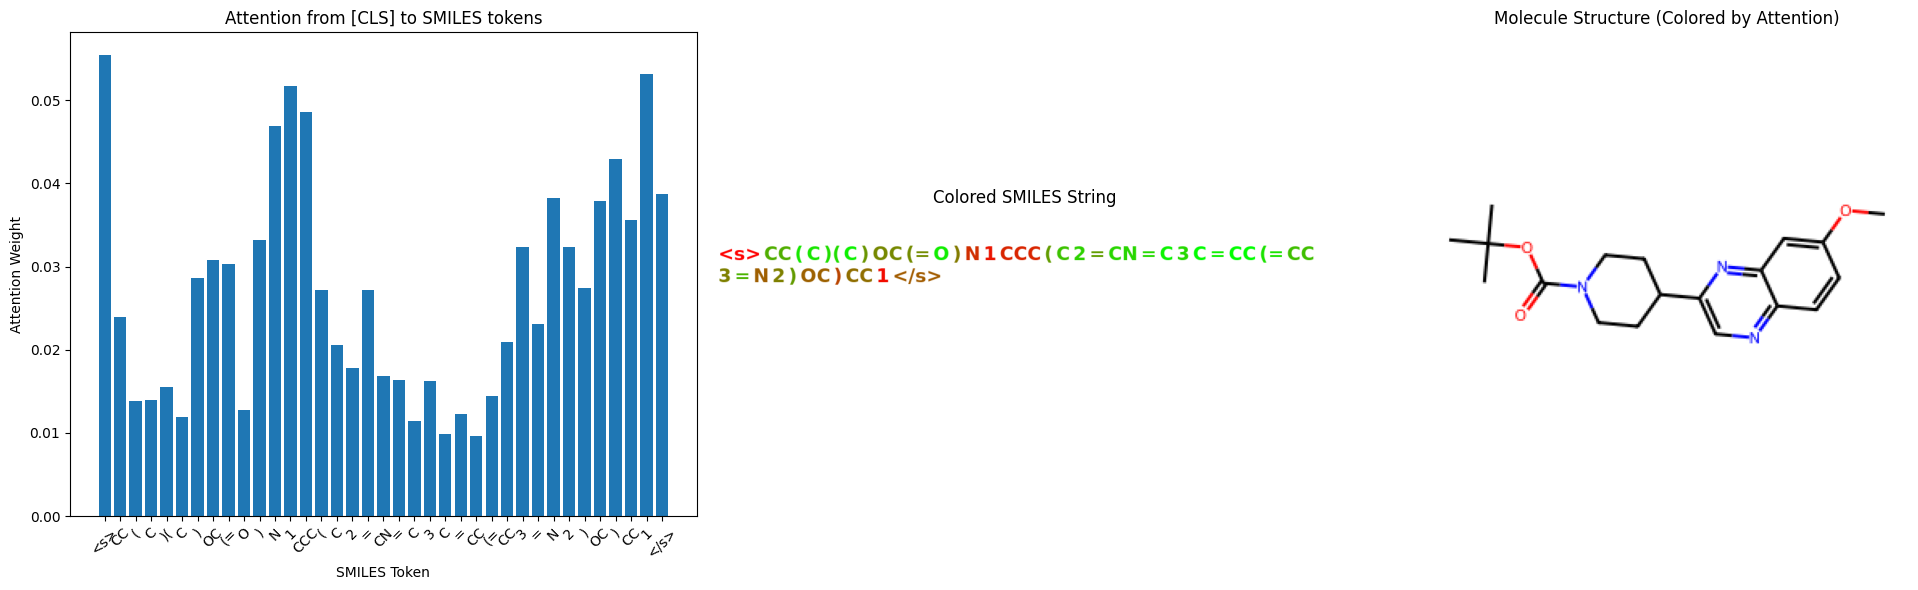

In [1]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from PIL import Image, ImageDraw, ImageFont
import numpy as np

import torch
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Load tokenizer and model (adjust to your checkpoint)
tokenizer = RobertaTokenizer.from_pretrained('seyonec/PubChem10M_SMILES_BPE_396_250')
model = RobertaModel.from_pretrained('seyonec/PubChem10M_SMILES_BPE_396_250', output_attentions=True)
model.eval()

# Input SMILES string
#smiles = "CC(C)NCC(O)COC1=CC=C(C=C1)C2=CC(=C(C=C2I)I)OC" # Amiodarone
smiles='CC(C)(C)OC(=O)N1CCC(C2=CN=C3C=CC(=CC3=N2)OC)CC1'

# Tokenize
inputs = tokenizer(smiles, return_tensors="pt")
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# Forward pass with attention output
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)

# Get attentions: shape (num_layers, batch_size, num_heads, seq_len, seq_len)
attentions = torch.stack(outputs.attentions)

# Mean across layers and heads: (batch_size, seq_len, seq_len)
mean_attention = attentions.mean(dim=0).mean(dim=1)

# Extract attention from [CLS] to all tokens: (batch_size, seq_len)
cls_attention = mean_attention[:, 0, :]

# Convert tokens
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
clean_tokens = [t.replace("Ġ", "").replace("Ċ", "").replace("Ġ", "") for t in tokens]
#clean_tokens = [t for t in tokens if t != "<s>"]

# Convert attention to numpy
attention_scores = cls_attention[0].detach().cpu().numpy()


# Function to create an image of the colored SMILES string with increased font size
def attention_colored_smiles_image(tokens, scores, font_size=30, image_width=1000):
    # Normalize the attention scores to [0, 1]
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min())

    # Calculate image height based on the number of tokens
    image_height = 200  # Increased height for better readability

    # Create a blank white image
    img = Image.new("RGB", (image_width, image_height), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    # Load a TrueType font and set the font size
    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"  # Common path for fonts on many systems
    font = ImageFont.truetype(font_path, font_size)  # Use a larger font size

    # Start drawing the tokens
    x_offset = 10  # initial x position for text
    y_offset = 50  # starting y position to give space from the top

    for token, score in zip(tokens, norm_scores):
        # Create color based on the score
        red = int(255 * score)
        green = int(255 * (1 - score))
        color = (red, green, 0)  # RGB color
        
        # Get the bounding box of the token (width, height)
        bbox = draw.textbbox((x_offset, y_offset), token, font=font)

        # Draw the text
        draw.text((x_offset, y_offset), token, font=font, fill=color)

        # Adjust x_offset for the next token and handle wrapping
        x_offset += bbox[2] - bbox[0] + 5  # Add a little space between tokens

        # Wrap to the next line if the token exceeds image width
        if x_offset > image_width - 50:  # Keep some margin
            x_offset = 10
            y_offset += font_size + 5  # Move to the next line

    return img

# Set up the figure layout: 1 row, 3 columns
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1. Attention Plot (Bar Chart)
axs[0].bar(range(len(clean_tokens)), attention_scores, tick_label=clean_tokens)
axs[0].set_xticklabels(clean_tokens, rotation=45, fontsize=10)
axs[0].set_title("Attention from [CLS] to SMILES tokens")
axs[0].set_xlabel("SMILES Token")
axs[0].set_ylabel("Attention Weight")
axs[0].tick_params(axis='x', labelrotation=45)

# 2. Colored SMILES String (with adjusted image width and larger font)
axs[1].axis('off')
smiles_image = attention_colored_smiles_image(clean_tokens, attention_scores, font_size=30, image_width=1000)  # Larger image width
axs[1].imshow(smiles_image)
axs[1].set_title("Colored SMILES String")

# 3. RDKit Molecule Visualization with attention-based coloring
# Convert SMILES string to RDKit molecule
mol = Chem.MolFromSmiles(smiles)
rdDepictor.Compute2DCoords(mol)

# Create atom colors based on attention scores
atom_colors = [(1, 1 - attention_scores[i], 1 - attention_scores[i]) for i in range(len(mol.GetAtoms()))]

# Draw molecule with attention-based coloring
mol_img = Draw.MolToImage(mol, size=(300, 300), kekulize=True, highlightAtomColors=atom_colors)
axs[2].imshow(mol_img)
axs[2].axis('off')
axs[2].set_title("Molecule Structure (Colored by Attention)")

# Apply tight layout to the figure as a whole
plt.tight_layout()

# Save the figure to a file (e.g., PNG)
output_path = "molecule_attention_visualization_combined.png"
plt.savefig('attention analysis.png')

plt.show()


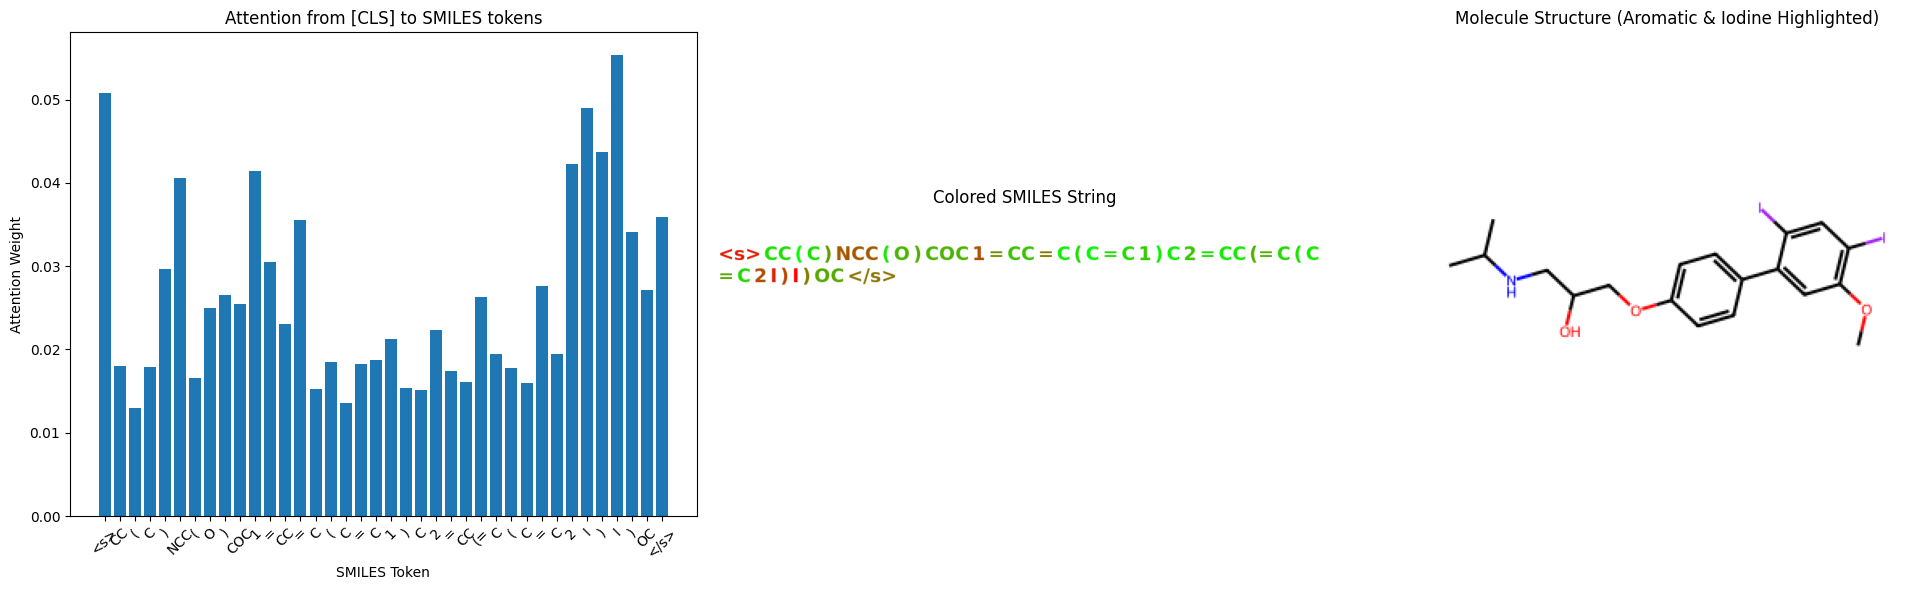

In [152]:

import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem import rdMolDescriptors
from PIL import Image, ImageDraw, ImageFont
import numpy as np

import torch
from transformers import RobertaTokenizer, RobertaModel
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Load tokenizer and model (adjust to your checkpoint)
tokenizer = RobertaTokenizer.from_pretrained('seyonec/PubChem10M_SMILES_BPE_396_250')
model = RobertaModel.from_pretrained('seyonec/PubChem10M_SMILES_BPE_396_250', output_attentions=True)
model.eval()

# Input SMILES string
smiles = "CC(C)NCC(O)COC1=CC=C(C=C1)C2=CC(=C(C=C2I)I)OC" # Amiodarone

# Tokenize
inputs = tokenizer(smiles, return_tensors="pt")
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# Forward pass with attention output
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)

# Get attentions: shape (num_layers, batch_size, num_heads, seq_len, seq_len)
attentions = torch.stack(outputs.attentions)

# Mean across layers and heads: (batch_size, seq_len, seq_len)
mean_attention = attentions.mean(dim=0).mean(dim=1)

# Extract attention from [CLS] to all tokens: (batch_size, seq_len)
cls_attention = mean_attention[:, 0, :]

# Convert tokens
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
clean_tokens = [t.replace("Ġ", "").replace("Ċ", "").replace("Ġ", "") for t in tokens]
#clean_tokens = [t for t in tokens if t != "<s>"]

# Convert attention to numpy
attention_scores = cls_attention[0].detach().cpu().numpy()


# Function to create an image of the colored SMILES string with increased font size
def attention_colored_smiles_image(tokens, scores, font_size=30, image_width=1000):
    # Normalize the attention scores to [0, 1]
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min())

    # Calculate image height based on the number of tokens
    image_height = 200  # Increased height for better readability

    # Create a blank white image
    img = Image.new("RGB", (image_width, image_height), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    # Load a TrueType font and set the font size
    font_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"  # Common path for fonts on many systems
    font = ImageFont.truetype(font_path, font_size)  # Use a larger font size

    # Start drawing the tokens
    x_offset = 10  # initial x position for text
    y_offset = 50  # starting y position to give space from the top

    for token, score in zip(tokens, norm_scores):
        # Create color based on the score
        red = int(255 * score)
        green = int(255 * (1 - score))
        color = (red, green, 0)  # RGB color
        
        # Get the bounding box of the token (width, height)
        bbox = draw.textbbox((x_offset, y_offset), token, font=font)

        # Draw the text
        draw.text((x_offset, y_offset), token, font=font, fill=color)

        # Adjust x_offset for the next token and handle wrapping
        x_offset += bbox[2] - bbox[0] + 5  # Add a little space between tokens

        # Wrap to the next line if the token exceeds image width
        if x_offset > image_width - 50:  # Keep some margin
            x_offset = 10
            y_offset += font_size + 5  # Move to the next line

    return img

# Set up the figure layout: 1 row, 3 columns
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# 1. Attention Plot (Bar Chart)
axs[0].bar(range(len(clean_tokens)), attention_scores, tick_label=clean_tokens)
axs[0].set_xticklabels(clean_tokens, rotation=45, fontsize=10)
axs[0].set_title("Attention from [CLS] to SMILES tokens")
axs[0].set_xlabel("SMILES Token")
axs[0].set_ylabel("Attention Weight")
axs[0].tick_params(axis='x', labelrotation=45)

# 2. Colored SMILES String (with adjusted image width and larger font)
axs[1].axis('off')
smiles_image = attention_colored_smiles_image(clean_tokens, attention_scores, font_size=30, image_width=1000)  # Larger image width
axs[1].imshow(smiles_image)
axs[1].set_title("Colored SMILES String")

# 3. RDKit Molecule Visualization with attention-based coloring
# Convert SMILES string to RDKit molecule
mol = Chem.MolFromSmiles(smiles)
rdDepictor.Compute2DCoords(mol)

# Find aromatic rings and iodine atoms
aromatic_atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetIsAromatic()]
iodine_atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetSymbol() == 'I']

# Create atom colors based on attention scores
atom_colors = [(1, 1 - attention_scores[i], 1 - attention_scores[i]) for i in range(len(mol.GetAtoms()))]

# Highlight aromatic rings and iodine atoms by changing their colors
highlight_colors = []
for i in range(len(mol.GetAtoms())):
    if i in aromatic_atoms:
        highlight_colors.append((0.1, 0.7, 0.1))  # Green for aromatic atoms
    elif i in iodine_atoms:
        highlight_colors.append((1, 0, 0))  # Red for iodine atoms
    else:
        highlight_colors.append(atom_colors[i])  # Default attention-based color

# Draw molecule with attention-based coloring and highlights
mol_img = Draw.MolToImage(mol, size=(300, 300), kekulize=True, highlightAtomColors=highlight_colors)
axs[2].imshow(mol_img)
axs[2].axis('off')
axs[2].set_title("Molecule Structure (Aromatic & Iodine Highlighted)")

# Apply tight layout to the figure as a whole
plt.tight_layout()

# Save the figure to a file (e.g., PNG)
output_path = "molecule_attention_visualization_combined_with_highlights.png"
plt.savefig(output_path, format='png')

plt.show()


In [4]:
herg_data = pd.read_csv("/home/f087s426/Research/Masters_Thesis/herg/hERG_IC50.csv")
herg_data=herg_data[['Smiles','pChEMBL Value']]
herg_data=herg_data.dropna()
herg_data['label'] = herg_data['pChEMBL Value'].apply(lambda x: 1 if x >= 6.5 else 0)
herg_data['group']= 1
herg_data['smiles_standarized']=herg_data['Smiles']
herg_data=herg_data[['smiles_standarized','label','group']]


In [5]:
herg_data

,smiles_standarized,label,group
0,O=C1NN=C(c2ccc(OC3CCN(C4CCC4)CC3)cc2)[C@@H]2C[...,0,1
1,COc1ccc([C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@H]2...,0,1
2,CN1C[C@H]2[C@@H](C1)[C@@H]2CN(Cc1cccc(OC(F)(F)...,0,1
3,O=C1CN(CCc2ccc(F)cc2)CCN1[C@H]1CCc2cc(CN3CCS(=...,0,1
4,COc1ccc2c(=O)n(CCO)c(C#N)c(-c3cccc(F)c3)c2c1,0,1
...,...,...,...
14355,COC(=O)N(C)c1c(N)nc(-n2nc(Cc3cccc(F)c3F)c3cccc...,0,1
14356,CCN(CC)CCNC(=O)c1c(C)[nH]c(/C=C2\C(=O)Nc3ccc(F...,0,1
14358,Cc1ccc(Oc2ccc(-c3nnn(CCN)n3)cc2)cc1,0,1
14359,COc1ccc(-c2ccc(C(=O)O)cc2C)cc1-c1cnc(N(C)C)nc1...,0,1
